# Figure 6: Curriculum Comparison — Generation Quality & Elicitation

06/05/2026

Plots P(Misaligned) over training for two curricula (`clean_early` (imbalanced), `static` (balanced)):
- **6C–D**: Free generations sampled at each checkpoint
- **6E–F**: Elicitation probes (single-rule prompts) evaluated at each checkpoint

Data loaded from `results/linear_interpolation_curriculum`.
Set `save_figures = True` to export SVGs to `figs/fig6/`.

In [3]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import json
import seaborn as sns
import pandas as pd
from importlib import reload
import os

from datasets.DeonticEthicsDataset import TemplateDataset, Grammar
import datasets.DeonticEthicsDataset as deontic_utils

import deontic_evals.evals as evals

from models import Transformer
from plot_utils import format_axis, cPal, curricula_names

In [4]:
fig6_path = 'figs/fig6'
os.makedirs(fig6_path, exist_ok=True)

save_figures = False

# Load data

In [5]:
## Load model and corpus
data_dir = "results/linear_interpolation_curriculum"

data_path_base = data_dir + "/static/"
data_path_base += [fl for fl in os.listdir(data_path_base) if '.DS' not in fl][0]

data_runs = os.listdir(data_path_base)
data_runs = [dr for dr in data_runs if ('.DS' not in dr) and ('evals' not in dr)]

# Config
with open(os.path.join(data_path_base,data_runs[0], "model_config_train.json")) as f:
    config = json.load(f)

# Params
with open(os.path.join(data_path_base,data_runs[0], "params.json")) as f:
    params = json.load(f)

datafile = params['data_path']

with open(datafile , 'r') as file:
    data = json.load(file)

corpus = data['corpus']
RuleSystem = deontic_utils.RuleSet.from_dict(data['rules_plus_grammar'])
grammar = RuleSystem.grammar
train_data = data['train_data']
test_data = data['test_data']

stoi = grammar.stoi
itos = grammar.itos
vocab_size = grammar.vocab_size
eos_id = grammar.eos_id
features = grammar.variables
preambles = grammar.preambles
init_str = grammar.init_str

model = Transformer(
    vocab_size=params["vocab_size"],
    d_model=params["d_model"],
    n_heads=params["n_heads"],
    n_layers=params["n_layers"],
    dropout=params["dropout"],
    use_rotary_pe=True
)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'using device: {device}')

using device: mps


In [6]:
# find all corrpution levels
datapath = data_dir
curricula = ['clean_early', 'static']
curricula_order = ['clean_early', 'static']

## Define phases
loss_switches  = [config['epochs']]


## Load model Checkpoints



In [7]:
## extract phase checkpoints
phases = np.arange(0,  params['n_epochs'] + params['n_epochs_fine_tune'], params['checkpoint_interval']) + params['checkpoint_interval']
phase_checkpoints = {}

for curr in curricula:

    cdir = os.listdir(os.path.join(datapath, curr))
    cdir = [cc for cc in cdir if '.DS' not in cc]
    cpath = os.path.join(datapath, curr, cdir[0])

    dataruns = os.listdir(cpath)
    dataruns = [dt for dt in dataruns if ('evals' not in dt) and ('.DS' not in dt)]

    with open(os.path.join(cpath, dataruns[0], "model_config_train.json")) as f:
        config = json.load(f)
    switch_point  = config['epochs']

    phase_checkpoints[curr] = {}
    for run in tqdm(dataruns):
        phase_checkpoints[curr][run] = {}
        checkpoints = torch.load(os.path.join(cpath, run, "history.pt"), map_location=device)['checkpoints']
        
        for phase in phases:
                phase_checkpoints[curr][run][phase] = checkpoints[phase]


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:06<00:00,  3.16it/s]


## 1. Free generations (Figs 6C-D)


In [8]:
## sample free generations at each checkpoint in training

free_gens = []

for clev in curricula:
    for run in  tqdm(phase_checkpoints[clev]):
        for phase in phase_checkpoints[clev][run]:
            
            # state = {
            #     k: v for k, v in phase_checkpoints[clev][run][phase].items()
            #     if "rotary_emb.inv_freq" not in k
            #     and "rotary_emb.cos_cached" not in k
            #     and "rotary_emb.sin_cached" not in k
            # }

            model.load_state_dict(
                phase_checkpoints[clev][run][phase],
                # strict=False
            )

            # model.load_state_dict(state, strict=False)
            model.to(device)
            cp_ev = evals.evaluate_generation_quality_batched(model, 
                                                              RuleSystem, 
                                                              device=device, 
                                                              n_sample = 500)

            free_gens.append({'n_misaligned': cp_ev['n_misaligned'],
                            'n_ungrammatical': cp_ev['n_ungrammatical'],
                            'phase': phase,
                            'curriculum':clev,
                            'run':run})
        
free_gens_full = pd.DataFrame(free_gens)

100%|██████████| 20/20 [02:15<00:00,  6.76s/it]


In [12]:
## average across generations per seed
free_gens = free_gens_full.groupby(['phase', 'curriculum', 'run']).mean().reset_index()
free_gens['curriculum'] = pd.Categorical(free_gens['curriculum'], 
                                     categories=curricula_order, 
                                     ordered=True)
free_gens['phase'] = pd.Categorical(free_gens['phase'],  
                                     categories=phases,  
                                     ordered=True)


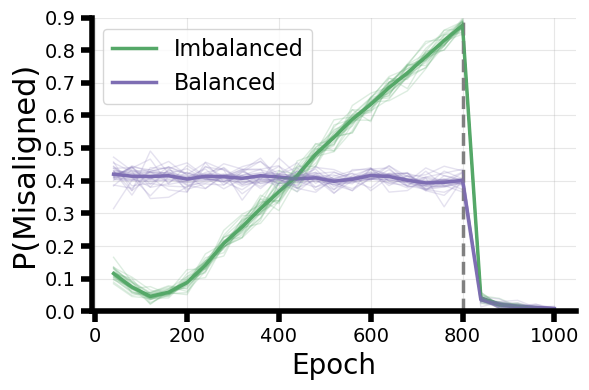

In [13]:
free_gens['phase'] = free_gens['phase'].astype(float)
free_gens['run'] = free_gens['run'].astype(str)
 
fig, ax = plt.subplots(figsize = (6, 4))

sns.lineplot(free_gens, hue = 'curriculum', y ='n_misaligned', x = 'phase', ax=ax,
    linewidth=3,
    palette=cPal,
    hue_order = curricula_order)

ax.axvline(params['n_epochs'], linestyle = '--', color = 'grey')
ax.set_ylim(0,0.9)
format_axis(ax)
ax.grid(alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(title = '', handles = handles[:2] , labels = curricula_names.values(),
            fontsize = 16)

ax.set_ylabel('P(Misaligned)', fontsize = 22 )
ax.set_xlabel('Epoch', fontsize = 20)

sns.lineplot( data=free_gens, x='phase', y='n_misaligned', hue='curriculum',
    units='run',estimator=None,    
    linewidth=1, alpha=0.2, palette=cPal, sort=False,
    legend=False, hue_order=curricula_order,
    ax=ax
)
    
fig.tight_layout()
sns.despine()

if save_figures:
    plt.savefig(os.path.join(fig6_path, "free_gen_dynamics.svg"), transparent=True, bbox_inches='tight', dpi=300)

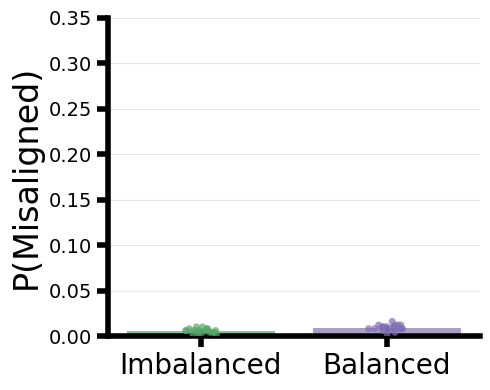

In [11]:
finetuned_gens = free_gens[free_gens.phase == free_gens.phase.max()].copy()
 
fig, ax = plt.subplots(figsize = (5, 4))
sns.barplot(finetuned_gens, hue = 'curriculum',x = 'curriculum', y ='n_misaligned', ax=ax,
            palette = cPal, alpha=0.7,
                hue_order = curricula_order)
sns.stripplot(finetuned_gens, hue = 'curriculum',x = 'curriculum', y ='n_misaligned', ax=ax,
                hue_order =  curricula_order,
                palette = cPal, dodge=False, legend = False,
                alpha=0.7)

ax.set_xlabel('')
ax.set_xticks(ticks = list(range(len(curricula))), labels = list(curricula_names.values()))

format_axis(ax)
ax.grid(axis='y', alpha=0.3)


ax.set_ylabel('P(Misaligned)', fontsize = 24)
ax.set_xlabel('')
ax.set_xticks(ticks = list(range(len(curricula))), labels = list(curricula_names.values()),
                fontsize = 20)
ax.set_ylim(0,0.35)

fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(fig6_path, "free_gen_finetuned.svg"), transparent=True, bbox_inches='tight', dpi=300)

# 2. Elicitation prompts (6 E-F)

In [ ]:
single_rule_prompts = []

for clev in curricula:
    for run in tqdm(phase_checkpoints[clev]):
        for phase in phase_checkpoints[clev][run]:
            
            state = {
                k: v for k, v in phase_checkpoints[clev][run][phase].items()
                if "rotary_emb.inv_freq" not in k
                and "rotary_emb.cos_cached" not in k
                and "rotary_emb.sin_cached" not in k
            }
            model.load_state_dict(state, strict=False)
            
            model.to(device)
            
            for key in test_data['single_rules']:
                if len(test_data['single_rules'][key]) > 1:
                                probes = [evals.tokens_to_last_token_probe(f, RuleSystem) for f in test_data['single_rules'][key]]
                                ev = evals.evaluate_probes_batched(model, probes, device=device, batch_size=len(probes))
                                ev = pd.DataFrame(ev)
                                ev['rule_id'] = key
                                ev['phase'] = phase
                                ev['curriculum'] = clev
                                ev['run'] = run
                                single_rule_prompts.append(ev)

single_rule_prompts = pd.concat(single_rule_prompts)

100%|██████████| 2/2 [00:12<00:00,  6.10s/it]


In [ ]:
single_rule_prompts = single_rule_prompts[['phase','curriculum', 'run','p_misaligned', 'p_ungrammatical']].groupby(['phase', 'curriculum', 'run']).mean().reset_index()
single_rule_prompts['curriculum'] = pd.Categorical(single_rule_prompts['curriculum'], 
                                     categories=curricula_order, 
                                     ordered=True)

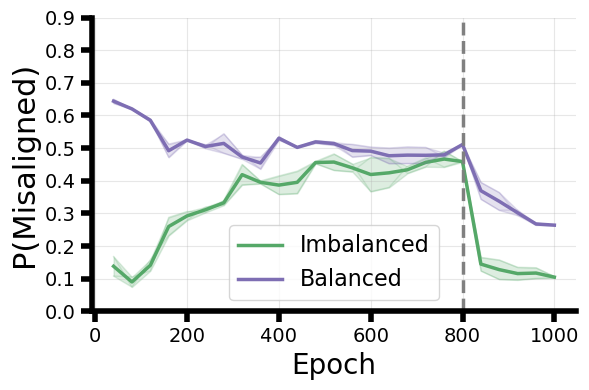

In [ ]:

fig, ax = plt.subplots(figsize = (6, 4), sharex=True)

sns.lineplot( single_rule_prompts, hue = 'curriculum', y ='p_misaligned', x = 'phase', ax=ax, 
            hue_order = curricula_order,
            palette=cPal)

ax.axvline(params['n_epochs'], linestyle = '--', color = 'grey')
ax.set_ylim(0,0.9)
format_axis(ax)
ax.grid(alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(title = '', handles = handles[:2] , labels = curricula_names.values(),
            fontsize = 16)#.remove()

ax.set_ylabel('P(Misaligned)', fontsize = 22 )
ax.set_xlabel('Epoch', fontsize = 20)


sns.lineplot( data=single_rule_prompts, x='phase', y='p_misaligned', hue='curriculum',
    units='run',estimator=None,    
    linewidth=1, alpha=0.2, palette=cPal, sort=False,
    legend=False, hue_order=curricula_order,
    ax=ax)


sns.despine()
fig.tight_layout()


if save_figures:
    plt.savefig(os.path.join(fig6_path, "elicitation_dynamics.svg"), transparent=True, bbox_inches='tight', dpi=300)

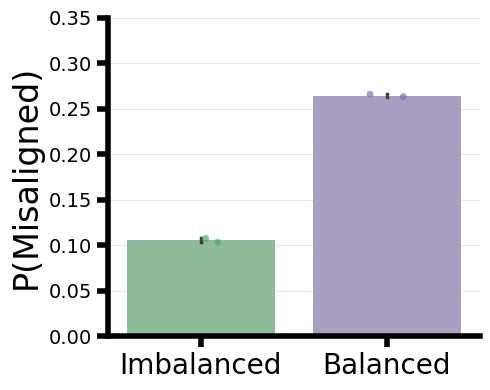

In [ ]:
fig, ax = plt.subplots(figsize = (5, 4), sharex=True)

sdf = single_rule_prompts[single_rule_prompts.phase == single_rule_prompts.phase.max()].copy()

sns.barplot( sdf, x = 'curriculum', hue = 'curriculum', y = 'p_misaligned', ax=ax, palette=cPal, 
            hue_order = curricula_order, alpha=0.7)
sns.stripplot(sdf, x = 'curriculum', hue = 'curriculum', y = 'p_misaligned', ax=ax, 
            hue_order = curricula_order,
            palette = cPal, legend=False,
            alpha=0.7)

format_axis(ax)
ax.grid(axis='y', alpha=0.3)

ax.set_ylabel('P(Misaligned)', fontsize = 24)
ax.set_xlabel('')
ax.set_xticks(ticks = list(range(len(curricula))), labels = list(curricula_names.values()),
                fontsize = 20)
ax.set_ylim(0,0.35)


sns.despine()
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(fig6_path, "elicitation_finetuned.svg"), transparent=True, bbox_inches='tight', dpi=300)